<a href="https://colab.research.google.com/github/yeyevtushenko/NLP_YevtushenkoBS-25/blob/main/NLP_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_%D0%84%D0%B2%D1%82%D1%83%D1%88%D0%B5%D0%BD%D0%BA%D0%BE_%D0%91%D0%A1_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Практична робота №7

## Реалізація RNN вручну: використовуючи код з прикладу, реалізуйте власну RNN через класи CharRNNCell та rnn_loop. Запустіть навчання моделі.

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib.pyplot as plt
import numpy as np
from random import sample
import os
import time
import pandas as pd

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


Кількість імен: 9408
Унікальних символів: 53
Перші 5 імен: [' Ababko*', ' Abaev*', ' Abagyan*', ' Abaidulin*', ' Abaidullin*']
Унікальні символи: [' ', "'", '*', ',', '-', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z', '\xa0']


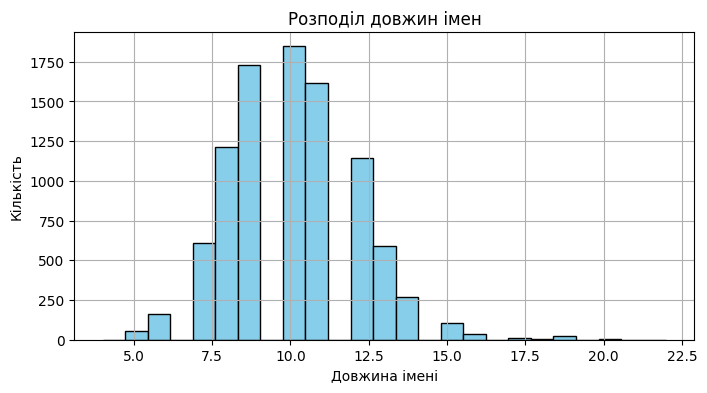

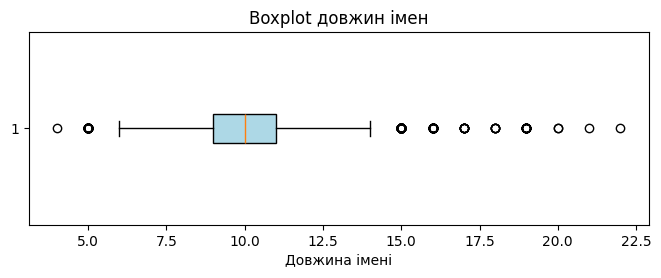

Приклад матриці токенів:
[[ 1  6 30 29 30 39 43  3  1  1  1  1  1  1  1  1  1  1  1  1  1  1]
 [ 1  6 30 29 33 49  3  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]
 [ 1  6 30 29 35 51 29 42  3  1  1  1  1  1  1  1  1  1  1  1  1  1]
 [ 1  6 30 29 37 32 48 40 37 42  3  1  1  1  1  1  1  1  1  1  1  1]
 [ 1  6 30 29 37 32 48 40 40 37 42  3  1  1  1  1  1  1  1  1  1  1]]


In [4]:
file_path = "names.txt"

if not os.path.exists(file_path):
    raise FileNotFoundError("Файл names.txt не знайдено. Завантаж його в Colab перед запуском.")

with open(file_path, "r", encoding="utf-8") as f:
    names = f.read().splitlines()

eos_token = "*"

names = [' ' + name + eos_token for name in names]

unique_chars = sorted(set("".join(names)))
char_to_id = {char: idx + 1 for idx, char in enumerate(unique_chars)}  # починаємо з 1
id_to_char = {idx: char for char, idx in char_to_id.items()}
vocab_size = len(char_to_id)

print(f"Кількість імен: {len(names)}")
print(f"Унікальних символів: {vocab_size}")
print(f"Перші 5 імен: {names[:5]}")
print(f"Унікальні символи: {unique_chars}")

name_lengths = [len(name) for name in names]

plt.figure(figsize=(8, 4))
plt.hist(name_lengths, bins=25, color="skyblue", edgecolor="black")
plt.title("Розподіл довжин імен")
plt.xlabel("Довжина імені")
plt.ylabel("Кількість")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 2.5))
plt.boxplot(name_lengths, vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title("Boxplot довжин імен")
plt.xlabel("Довжина імені")
plt.show()

def to_matrix(data, token_dict, max_len=None, dtype="int32", batch_first=True):
    max_len = max_len or max(map(len, data))
    data_ix = np.zeros((len(data), max_len), dtype=dtype) + token_dict[" "]

    for i, name in enumerate(data):
        line_ix = [token_dict[c] for c in name]
        data_ix[i, :len(line_ix)] = line_ix

    if not batch_first:
        data_ix = np.transpose(data_ix)

    return data_ix

matrix = to_matrix(names, char_to_id)

print("Приклад матриці токенів:")
print(matrix[:5])

class CharRNNCell(nn.Module):
    def __init__(self, num_tokens, embedding_size=16, rnn_num_units=64):
        super().__init__()
        self.num_units = rnn_num_units

        self.embedding = nn.Embedding(num_tokens, embedding_size)

        self.rnn_update = nn.Linear(embedding_size + rnn_num_units, rnn_num_units)

        self.rnn_to_logits = nn.Linear(rnn_num_units, num_tokens)

    def forward(self, x, h_prev):

        x_emb = self.embedding(x)
        x_and_h = torch.cat([x_emb, h_prev], dim=1)
        h_next = self.rnn_update(x_and_h)
        h_next = torch.tanh(h_next)

        logits = self.rnn_to_logits(h_next)

        return h_next, F.log_softmax(logits, dim=-1)

    def initial_state(self, batch_size):
        return torch.zeros(batch_size, self.num_units, device=device)

def rnn_loop(rnn, batch_index):
    batch_size, max_length = batch_index.size()
    hid_state = rnn.initial_state(batch_size)
    logprobs = []

    for x_t in batch_index.transpose(0, 1):
        hid_state, logp_next = rnn(x_t, hid_state)
        logprobs.append(logp_next)

    return torch.stack(logprobs, dim=1)

def generate_sample(rnn, seed_phrase=" ", max_length=20, temperature=1.0):
    rnn.eval()

    if not seed_phrase:
        seed_phrase = " "

    x_sequence = [char_to_id.get(token, char_to_id[" "]) for token in seed_phrase]
    if len(x_sequence) == 0:
        raise ValueError("Seed phrase is empty or contains invalid characters.")

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64, device=device)
    hid_state = rnn.initial_state(batch_size=1)

    for t in range(len(seed_phrase) - 1):
        hid_state, _ = rnn(x_sequence[:, t], hid_state)

    for _ in range(max_length - len(seed_phrase)):
        hid_state, logp_next = rnn(x_sequence[:, -1], hid_state)

        probs = torch.softmax(logp_next / temperature, dim=-1).detach().cpu().numpy()[0]
        next_ix = np.random.choice(len(probs), p=probs)

        x_sequence = torch.cat(
            [x_sequence, torch.tensor([[next_ix]], dtype=torch.int64, device=device)],
            dim=1
        )

        next_char = id_to_char.get(next_ix, " ")

        if next_char == eos_token:
            break

    generated = "".join(
        [id_to_char.get(ix, " ") for ix in x_sequence.detach().cpu().numpy()[0] if ix in id_to_char]
    )

    generated = generated.replace(eos_token, "")
    return generated

num_tokens = vocab_size + 1
embedding_size = 128
rnn_num_units = 128

char_rnn = CharRNNCell(
    num_tokens=num_tokens,
    embedding_size=embedding_size,
    rnn_num_units=rnn_num_units
).to(device)

opt = torch.optim.Adam(char_rnn.parameters(), lr=0.001)
history = []

MAX_LENGTH = max(name_lengths)

###Запустіть навчання моделі.

In [5]:
n_iters = 3000
batch_size = 32

start_time = time.time()

for i in range(n_iters):
    batch_names = sample(names, batch_size)
    batch_ix = to_matrix(batch_names, char_to_id, max_len=MAX_LENGTH)
    batch_ix = torch.tensor(batch_ix, dtype=torch.int64, device=device)

    logp_seq = rnn_loop(char_rnn, batch_ix)

    predictions_logp = logp_seq[:, :-1]
    actual_next_tokens = batch_ix[:, 1:]

    loss = -torch.mean(
        torch.gather(predictions_logp, dim=2, index=actual_next_tokens[:, :, None])
    )

    loss.backward()
    opt.step()
    opt.zero_grad()

    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss.item():.4f}")
        history.append(loss.item())

print(f"Час навчання: {time.time() - start_time:.2f} сек")

Iteration 0, Loss: 4.0692
Iteration 100, Loss: 0.9353
Iteration 200, Loss: 0.9363
Iteration 300, Loss: 0.8741
Iteration 400, Loss: 0.8959
Iteration 500, Loss: 0.8928
Iteration 600, Loss: 0.9014
Iteration 700, Loss: 0.8474
Iteration 800, Loss: 0.8485
Iteration 900, Loss: 0.8422
Iteration 1000, Loss: 0.8422
Iteration 1100, Loss: 0.8133
Iteration 1200, Loss: 0.8097
Iteration 1300, Loss: 0.8444
Iteration 1400, Loss: 0.7353
Iteration 1500, Loss: 0.6742
Iteration 1600, Loss: 0.7064
Iteration 1700, Loss: 0.7251
Iteration 1800, Loss: 0.7799
Iteration 1900, Loss: 0.7465
Iteration 2000, Loss: 0.7829
Iteration 2100, Loss: 0.7725
Iteration 2200, Loss: 0.7573
Iteration 2300, Loss: 0.7635
Iteration 2400, Loss: 0.7113
Iteration 2500, Loss: 0.7409
Iteration 2600, Loss: 0.7080
Iteration 2700, Loss: 0.7309
Iteration 2800, Loss: 0.7344
Iteration 2900, Loss: 0.7480
Час навчання: 40.33 сек


###Візуалізуйте графік втрат під час навчання.

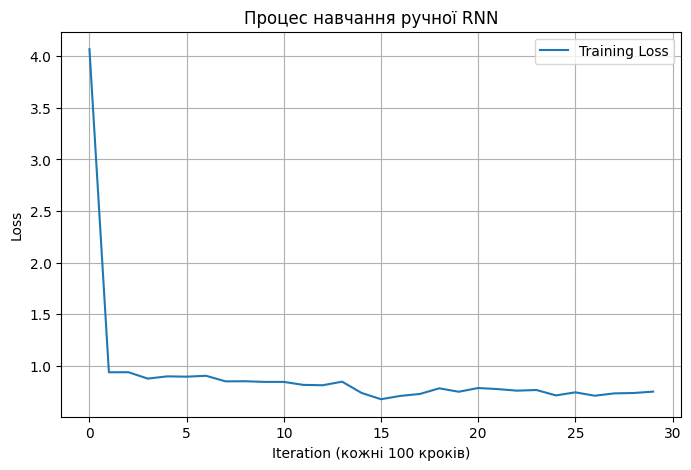

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history, label="Training Loss")
plt.xlabel("Iteration (кожні 100 кроків)")
plt.ylabel("Loss")
plt.legend()
plt.title("Процес навчання ручної RNN")
plt.grid(True)
plt.show()

assert np.mean(history[:10]) > np.mean(history[-10:]), "RNN didn't converge."

###Використовуйте різні значення температури (temperature=0.01, 0.2, 0.5, 1.0, 2.0) для генерації нових імен.

In [6]:
print("\nGenerated Names:")
for temp in [0.01, 0.2, 0.5, 1.0, 2.0]:
    print(f"\nТемпература {temp}:")
    for _ in range(5):
        print(generate_sample(char_rnn, seed_phrase="Ab", temperature=temp))


Generated Names:

Температура 0.01:
Abakin
Abakin
Abakin
Abakin
Abakin

Температура 0.2:
Abakin
Abov
Aberganov
Abakin
Abov

Температура 0.5:
Abarikhin
Abaroff
Abrihov
Abasin
Abaev

Температура 1.0:
Abwihin
Abekson
Abov
Abdzakoff
Abkercherbergan

Температура 2.0:
Abgomj
Abenn
Abovyah
Abohov
Abtulento


###Які шаблони імен генерує модель? Як температура впливає на різноманітність згенерованих імен?

Модель відтворює типові шаблони прізвищ: суфікси -ov, -in, -sky, характерні початки (Abr-, Abro-) і реалістичну довжину слів. Чим більше температура, тим більше варіантів, але від дуже високих значень якість погіршується. Тому, 0.5 це найоптимальніше значення.

##Реалізація RNN через nn.RNN. Використовуйте клас CharRNN з вбудованим модулем nn.RNN.

In [8]:
class CharRNN(nn.Module):
    def __init__(self, num_tokens, embedding_size=128, hidden_dim=128):
        super().__init__()
        self.num_tokens = num_tokens
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(num_tokens, embedding_size)
        self.rnn = nn.RNN(
            input_size=embedding_size,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.output = nn.Linear(hidden_dim, num_tokens)

    def forward(self, x, h0=None):
        emb = self.embedding(x)
        out, h_n = self.rnn(emb, h0)
        logits = self.output(out)
        log_probs = F.log_softmax(logits, dim=-1)
        return log_probs, h_n

    def initial_state(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_dim, device=device)

def generate_sample_rnn(model, seed_phrase=" ", max_length=20, temperature=1.0):
    model.eval()

    if not seed_phrase:
        seed_phrase = " "

    seq = [char_to_id.get(ch, char_to_id[" "]) for ch in seed_phrase]
    x = torch.tensor([seq], dtype=torch.long, device=device)

    h = model.initial_state(batch_size=1)

    log_probs, h = model(x, h)

    generated = seed_phrase

    current_token = x[:, -1:]

    for _ in range(max_length - len(seed_phrase)):
        log_probs, h = model(current_token, h)
        probs = torch.softmax(log_probs[:, -1, :] / temperature, dim=-1).detach().cpu().numpy()[0]

        next_ix = np.random.choice(len(probs), p=probs)
        next_char = id_to_char.get(next_ix, " ")

        if next_char == eos_token:
            break

        generated += next_char
        current_token = torch.tensor([[next_ix]], dtype=torch.long, device=device)

    return generated

num_tokens = vocab_size + 1
embedding_size = 128
hidden_dim = 128

rnn_model = CharRNN(
    num_tokens=num_tokens,
    embedding_size=embedding_size,
    hidden_dim=hidden_dim
).to(device)

optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
history_rnn = []

###Проведіть навчання моделі.

In [9]:
n_iters = 3000
batch_size = 32

start_time = time.time()

for i in range(n_iters):
    batch_names = sample(names, batch_size)
    batch_ix = to_matrix(batch_names, char_to_id, max_len=MAX_LENGTH)
    batch_ix = torch.tensor(batch_ix, dtype=torch.long, device=device)

    x_batch = batch_ix[:, :-1]
    y_batch = batch_ix[:, 1:]

    log_probs, _ = rnn_model(x_batch)

    loss = -torch.mean(
        torch.gather(log_probs, dim=2, index=y_batch.unsqueeze(-1))
    )

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss.item():.4f}")
        history_rnn.append(loss.item())

print(f"Час навчання: {time.time() - start_time:.2f} сек")

Iteration 0, Loss: 3.9438
Iteration 100, Loss: 1.0671
Iteration 200, Loss: 0.9497
Iteration 300, Loss: 0.9168
Iteration 400, Loss: 0.8688
Iteration 500, Loss: 0.8266
Iteration 600, Loss: 0.8242
Iteration 700, Loss: 0.8248
Iteration 800, Loss: 0.8521
Iteration 900, Loss: 0.7513
Iteration 1000, Loss: 0.9009
Iteration 1100, Loss: 0.7898
Iteration 1200, Loss: 0.8061
Iteration 1300, Loss: 0.7702
Iteration 1400, Loss: 0.8225
Iteration 1500, Loss: 0.7667
Iteration 1600, Loss: 0.7755
Iteration 1700, Loss: 0.7628
Iteration 1800, Loss: 0.7438
Iteration 1900, Loss: 0.7514
Iteration 2000, Loss: 0.7853
Iteration 2100, Loss: 0.7555
Iteration 2200, Loss: 0.7423
Iteration 2300, Loss: 0.7284
Iteration 2400, Loss: 0.7646
Iteration 2500, Loss: 0.6971
Iteration 2600, Loss: 0.7161
Iteration 2700, Loss: 0.7376
Iteration 2800, Loss: 0.6725
Iteration 2900, Loss: 0.7515
Час навчання: 6.79 сек


###Візуалізуйте графік втрат під час навчання.

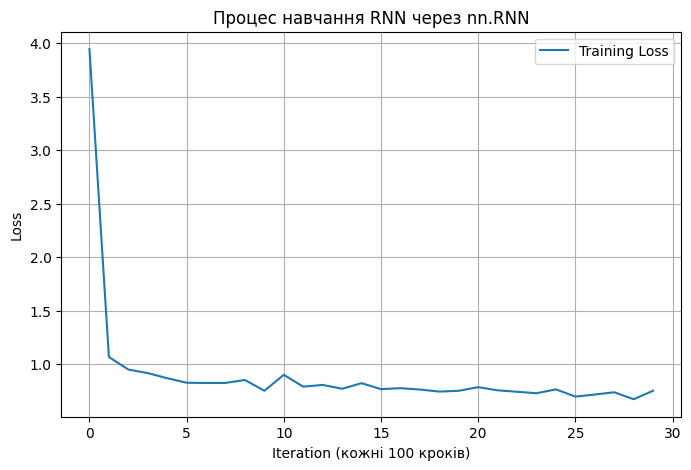

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history_rnn, label="Training Loss")
plt.xlabel("Iteration (кожні 100 кроків)")
plt.ylabel("Loss")
plt.title("Процес навчання RNN через nn.RNN")
plt.legend()
plt.grid(True)
plt.show()

###Використовуйте ті самі значення температури (temperature=0.01, 0.2, 0.5, 1.0, 2.0) для генерації нових імен.

In [11]:
print("\nGenerated Names (nn.RNN):")
for temp in [0.01, 0.2, 0.5, 1.0, 2.0]:
    print(f"\nТемпература {temp}:")
    for _ in range(5):
        print(generate_sample_rnn(rnn_model, seed_phrase="Ab", temperature=temp))


Generated Names (nn.RNN):

Температура 0.01:
Abakoff
Abakoff
Abakoff
Abakoff
Abakoff

Температура 0.2:
Aberg
Abakin
Abakin
Abakoff
Abakoff

Температура 0.5:
Abakov
Abakoff
Abagin
Abaginoff
Abertsev

Температура 1.0:
Abesff
Aberoff
Abeja
Abasoff
Abyshiloff

Температура 2.0:
AbesriMihaNov
Abakilzukym-Yuk-Gtos
Ababz'JCNy,n
AbRerfohin
Abashchik


###Як змінюються результати у порівнянні з першою реалізацією? Чи спостерігаються покращення в якості генерації?

Модель на основі nn.RNN генерує більш стабільні та правдоподібні імена. У порівнянні з ручною реалізацією тут частіше з’являються реалістичні шаблони на кшталт Abakoff, Abakov, Abagin, тоді як ручна модель частіше давала менш природні варіанти при високій температурі. Так, покращення спостерігаються, але при малій температурі, а при високому значенні результат залишається поганим

##Порівняння обох підходів. Створіть таблицю для порівняння: час навчання: який підхід вимагає більше часу для навчання? якість генерації: які імена виглядають реалістичніше? складність реалізації: який підхід виявився простішим у реалізації? Використайте 5-10 прикладів імен для кожного підходу, щоб продемонструвати різницю.

In [16]:
def get_training_time(start_time, end_time):
    return round(end_time - start_time, 2)

def get_loss_stats(history):
    return round(history[-1], 4), round(min(history), 4)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def generate_examples(model, generator_fn, temps):
    results = {}
    for t in temps:
        results[str(t)] = [generator_fn(model, "Ab", temperature=t) for _ in range(5)]
    return results

manual_final_loss, manual_best_loss = get_loss_stats(history)
builtin_final_loss, builtin_best_loss = get_loss_stats(history_rnn)

manual_params = count_params(char_rnn)
builtin_params = count_params(rnn_model)

temps = [0.01, 0.2, 0.5, 1.0, 2.0]

manual_names = generate_examples(char_rnn, generate_sample, temps)
builtin_names = generate_examples(rnn_model, generate_sample_rnn, temps)


comparison = pd.DataFrame([
    {
        "Критерій": "Останній loss",
        "Ручна RNN": manual_final_loss,
        "nn.RNN": builtin_final_loss
    },
    {
        "Критерій": "Найкращий loss",
        "Ручна RNN": manual_best_loss,
        "nn.RNN": builtin_best_loss
    },
    {
        "Критерій": "Кількість параметрів",
        "Ручна RNN": manual_params,
        "nn.RNN": builtin_params
    },
    {
        "Критерій": "Якість генерації",
        "Ручна RNN": "Більше шуму при високій температурі",
        "nn.RNN": "Більш стабільна генерація"
    },
    {
        "Критерій": "Складність реалізації",
        "Ручна RNN": "Складна",
        "nn.RNN": "Проста"
    }
])

print("=== ПОРІВНЯННЯ ===")
display(comparison)

rows = []
for t in temps:
    rows.append({
        "Температура": t,
        "Ручна RNN": ", ".join(manual_names[str(t)]),
        "nn.RNN": ", ".join(builtin_names[str(t)])
    })

examples_df = pd.DataFrame(rows)

print("\n=== ПРИКЛАДИ ІМЕН ===")
display(examples_df)

=== ПОРІВНЯННЯ ===


,Критерій,Ручна RNN,nn.RNN
0,Останній loss,0.748,0.7515
1,Найкращий loss,0.6742,0.6725
2,Кількість параметрів,46774,46902
3,Якість генерації,Більше шуму при високій температурі,Більш стабільна генерація
4,Складність реалізації,Складна,Проста



=== ПРИКЛАДИ ІМЕН ===


,Температура,Ручна RNN,nn.RNN
0,0.01,"Abakin, Abakin, Abakin, Abakin, Abakin","Abakoff, Abakoff, Abakoff, Abakoff, Abakoff"
1,0.20,"Abov, Abakin, Abaev, Aboff, Abov","Abakin, Abakoff, Abakoff, Abakoff, Abakoff"
2,0.50,"Aberg, Abov, Abov, Abdikoff, Abakin","Abakoff, Abakin, Abakimov, Aberov, Abakin"
3,1.00,"Abem'Dmen, Abov, Abenkin, Ablezinnya, Abakoff","Aberg, Abafov, Abriyat, Abakimoff, Abulgaev"
4,2.00,"Aburakidhaili, Abaev, Abdyazi-SHLetchChals, Ab...","Abern, AbavawnahnVyRf, Abizdeiny, AbeLishnjel-..."


##Як температура впливає на результати генерації? Яке значення підходить найкраще? Чи є переваги використання вбудованої RNN порівняно з ручною реалізацією? Що станеться, якщо збільшити/зменшити розмір прихованого шару (hidden_dim) або кількість епох навчання?

Попередні етапи показали те, що температура суттєво впливає на результати генерації імен. При низьких значеннях модель генерує майже однакові та передбачувані варіанти, при середніх значеннях з’являється оптимальний баланс між якістю та різноманітністю, а при високих значеннях результати стають більш випадковими та менш реалістичними. Найкращим значенням у проведених експериментах виявилась температура близько 0.5. Також експерименти показали, що використання вбудованої моделі nn.RNN має переваги над ручною реалізацією. Вона простіша у використанні, забезпечує стабільніше навчання та генерує більш правдоподібні імена. Зміна розміру прихованого шару (hidden_dim) впливає на здатність моделі вивчати складні залежності: збільшення цього параметра покращує якість генерації, але підвищує час навчання і ризик перенавчання, тоді як зменшення призводить до спрощення моделі та погіршення результатів. Кількість епох навчання також є важливим фактором: при збільшенні кількості епох модель краще навчається, однак після певного моменту можливе перенавчання. При недостатній кількості епох модель не встигає засвоїти закономірності, що призводить до гіршої якості генерації.

##Контрольні питання

###1. Що таке рекурентна нейронна мережа (RNN), і як вона використовується для генерації тексту?
RNN — це нейронна мережа, яка обробляє послідовності, передаючи інформацію через прихований стан між кроками. Для генерації тексту вона передбачає наступний символ на основі попередніх.
###2. Чому в задачі генерації тексту використовується softmax з температурою? Як температура впливає на результати?
Softmax перетворює логіти в ймовірності. Температура керує випадковістю: низька — більш детерміновано, висока — більш випадково.
###3. Яка різниця між ручною реалізацією RNN (через CharRNNCell) та використанням вбудованого модуля nn.RNN?
Ручна реалізація дає більше контролю, але складніша. nn.RNN — простіша, оптимізована і стабільніша.
###4. Що таке EOS-токен (*) і яку роль він відіграє в процесі генерації?
EOS (*) — спеціальний символ кінця послідовності, який сигналізує моделі, коли зупинити генерацію.
###5. Які параметри RNN впливають на якість генерації (наприклад, розмір ембеддингів, кількість прихованих шарів, кількість епох)?
Розмір ембеддингів, hidden_dim, кількість шарів, кількість епох і learning rate.
###6. Чому в процесі навчання RNN використовується функція втрат CrossEntropyLoss?
Вона вимірює різницю між передбаченим розподілом і правильним символом, що підходить для задач класифікації.
###7. Що означає "hidden state" у RNN, і як він зберігає інформацію про попередні символи?
Це внутрішній стан, який зберігає інформацію про попередні символи і передається між кроками.
###8. Як можна покращити якість генерації тексту при використанні RNN?
Збільшити дані, підібрати параметри, збільшити hidden_dim, використовувати кращі архітектури (LSTM/GRU).
###9. Що відбувається, якщо навчати RNN із занадто малим або занадто великим розміром ембеддингів?
Малий — недостатньо інформації, великий — перенавчання і повільне навчання.
###10. Які проблеми виникають при навчанні RNN, і як їх можна вирішити (наприклад, проблема затухаючих градієнтів)?
Основна — затухаючі градієнти. Вирішення: LSTM/GRU, нормалізація, правильний вибір параметрів.